<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd

In [ ]:
#Importation de la librairie plotly express
import plotly.express as px

In [ ]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [ ]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("/content/web.xlsx")

#Importation du fichier erp.xlsx
df_erp = pd.read_excel("/content/erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison = pd.read_excel("/content/liaison.xlsx")

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print("il y a {} colonnes".format(df_erp.shape[1]))
#La nature des données dans chacune des colonnes
df_erp.dtypes
print(df_erp.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
nombre_total_valeurs_erp = df_erp.count()
print("Nombre total de valeurs :", nombre_total_valeurs_erp)


il y a 6 colonnes
product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object
Nombre total de valeurs : product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64


In [ ]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [ ]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
doublons_erp = df_erp["product_id"].duplicated()
print(doublons_erp)
print("absence de doublon dans la table:{}".format(doublons_erp.size==df_erp.shape[0]))

0      False
1      False
2      False
3      False
4      False
       ...  
820    False
821    False
822    False
823    False
824    False
Name: product_id, Length: 825, dtype: bool
absence de doublon dans la table:True


In [ ]:
#Afficher les valeurs distinctes de la colonne stock_status
stock_status_uniques = df_erp["stock_status"].unique()
print(stock_status_uniques)
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
#Stock_quantity

['instock' 'outofstock']


In [ ]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
def quantite_stock(stock_quantity):
  if stock_quantity >0:
        return "instock"
  else:
        return "outofstock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(quantite_stock)
print(df_erp)

     product_id  onsale_web  price  stock_quantity stock_status  \
0          3847           1   24.2              16      instock   
1          3849           1   34.3              10      instock   
2          3850           1   20.8               0   outofstock   
3          4032           1   14.1              26      instock   
4          4039           1   46.0               3   outofstock   
..          ...         ...    ...             ...          ...   
820        7203           0   45.0              30      instock   
821        7204           0   45.0               9      instock   
822        7247           1   54.8               6      instock   
823        7329           0   26.5              14      instock   
824        7338           1   16.3              40      instock   

     purchase_price stock_status_2  
0             12.88        instock  
1             17.54        instock  
2             10.64     outofstock  
3              6.92        instock  
4         

In [ ]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
control_identique = df_erp["stock_status"] == df_erp["stock_status_2"]
print(control_identique)

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool


In [ ]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
nb_true = sum(control_identique)  # True est traité comme 1, False comme 0
print(f"Nombre de True : {nb_true}")

# Compter les False
nb_false = len(control_identique) - nb_true
print(f"Nombre de False : {nb_false}")

Nombre de True : 823
Nombre de False : 2


In [ ]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
print(df_erp[control_identique == False])

     product_id  onsale_web  price  stock_quantity stock_status  \
4          4039           1   46.0               3   outofstock   
398        4885           1   18.7               0      instock   

     purchase_price stock_status_2  
4             23.77        instock  
398            9.66     outofstock  


In [ ]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp['product_id'] == 4039, 'stock_status'] = 'instock'
df_erp.loc[df_erp['product_id'] == 4885, 'stock_status'] = 'outofstock'
#Verification en utilisant le même code que plus haut pour afficher les problemes
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [ ]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
prix_nul_negatif_nonreseig = df_erp[(df_erp["price"].isna())| (df_erp["price"] <= 0)|(df_erp["price"] == 0)]
print(prix_nul_negatif_nonreseig)

#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(df_erp["price"].isna())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
Prix_min= df_erp["price"].min()
print("Le prix minimum est de",Prix_min)
#Afficher le prix maximum de la colonne "price"
Prix_max= df_erp["price"].max()
print("Le prix maximum est de",Prix_max)
#Afficher les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
Prix_inf_a_0 = df_erp["price"] < 0
print(df_erp[df_erp["price"]<0].count)
# création du dataframe avec uniquement le prix positif
df_erp_clean = df_erp[df_erp["price"]>0]

     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  
Nombres d'article avec un prix non renseignés: 0      False
1      False
2      False
3      False
4      False
       ...  
820    False
821    False
822    False
823    False
824    False
Name: price, Length: 825, dtype: bool
Le prix minimum est de -20.0
Le prix maximum est de 225.0
<bound method DataFrame.count of      product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [ ]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
Verif_stock = df_erp[(df_erp["stock_quantity"].isna())| (df_erp["stock_quantity"] <= 0)|(df_erp["stock_quantity"] == 0)]
print(Verif_stock)
#Afficher la quantité minimum de la colonne "stock_quantity"
Stock_min= df_erp["stock_quantity"].min()
print("Le stock minimum est de",Stock_min)
#Afficher la quantité maximum de la colonne "stock_quantity"
Stock_max= df_erp["stock_quantity"].max()
print("Le stock maximum est de",Stock_max)
#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
Stock_inf_a_0 = df_erp["stock_quantity"] < 0
print(Stock_inf_a_0)
#remettre à 0 le stock négatif
df_erp_clean=df_erp.loc[df_erp["stock_quantity"]<0]=0
print(df_erp_clean)

     product_id  onsale_web  price  stock_quantity stock_status  \
2          3850           1   20.8               0   outofstock   
8          4043           1   60.0               0   outofstock   
11         4047           1   18.3               0   outofstock   
15         4051           1    7.7               0   outofstock   
16         4052           1   33.7               0   outofstock   
..          ...         ...    ...             ...          ...   
723        6301           1   40.5               0   outofstock   
726        6327           0   28.5               0   outofstock   
752        6632           1   52.7               0   outofstock   
774        6900           0   30.0               0   outofstock   
775        6901           0   20.0               0   outofstock   

     purchase_price stock_status_2  
2             10.64     outofstock  
8             29.45     outofstock  
11             9.93     outofstock  
15             4.14     outofstock  
16        

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
Onsale_web_data = df_erp["onsale_web"].unique()
print(Onsale_web_data)
"indique si vendu sur le web=1 sinon 0= seulement en magasin"

[1 0]


'indique si vendu sur le web=1 sinon 0= seulement en magasin'

In [ ]:
#Quelles sont les colonnes à conserver selon vous?
"gardez product_id,onsale_web,price(Px de vente),stock_quantity,purchase_price(prix d'achat),stock_status"

"gardez product_id,onsale_web,price(Px de vente),stock_quantity,purchase_price(prix d'achat),stock_status"

In [ ]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp_clean=df_erp.drop(columns="stock_status_2")
df_erp_clean.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
prix_dachat = df_erp[(df_erp["purchase_price"].isna())| (df_erp["purchase_price"] <= 0)|(df_erp["purchase_price"] == 0)]
print(prix_dachat)
#Afficher le prix minimum de la colonne "purchase_price"
Prix_dachat_min= df_erp["purchase_price"].min()
print("Le prix minmum est de",Prix_dachat_min)
#Afficher le prix maximum de la colonne "purchase_price"
Prix_dachat_max= df_erp["purchase_price"].max()
print("Le prix maximum est de",Prix_dachat_max)

     product_id  onsale_web  price  stock_quantity stock_status  \
449           0           0    0.0               0            0   
573           0           0    0.0               0            0   

     purchase_price stock_status_2  
449             0.0              0  
573             0.0              0  
Le prix minmum est de 0.0
Le prix maximum est de 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [ ]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))
#Nombre d'observations
print("il y a {} observations".format(df_web.shape[0]))
#Nombre de caractéristiques
df_web.dtypes
print(df_web.dtypes)

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)
il y a 1513 observations
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_co

In [ ]:
#Consulter le nombre de colonnes
print("il y a {} colonnes".format(df_web.shape[1]))
#La nature des données dans chacune des colonnes
df_web.dtypes
print(df_web.dtypes)
#Le nombre de valeurs présentes dans chacune
nombre_total_valeurs_web = df_web.count()
print("Nombre total de valeurs :", nombre_total_valeurs_web)

il y a 29 colonnes
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent                     float64
guid                 

In [ ]:
#Selon vous, quelles sont les colonnes à conserver ?
"colonne à conserver sku/total sales/tax_status/product_type/post_title/post_name/post_type"

'colonne à conserver sku/total sales/tax_status/product_type/post_title/post_name/post_type'

In [ ]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web_clean=df_web.drop(columns=["virtual","downloadable","rating_count","average_rating","tax_class","post_author","post_date","post_date_gmt","post_content","post_excerpt","post_status","comment_status","ping_status","post_password","post_modified","post_modified_gmt","post_content_filtered","post_parent","menu_order","post_mime_type","comment_count","guid"],axis=1)
df_web_clean.head()

,sku,total_sales,tax_status,product_type,post_title,post_name,post_type
0,11862,3.0,NaN,Vin,Gilles Robin Hermitage Rouge 2012,gilles-robin-hermitage-2012,attachment
1,16057,5.0,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,pelle-sancerre-rouge-la-croix-au-garde-2017,attachment
2,14692,5.0,taxable,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,fonreaud-bordeaux-blanc-le-cygne-2016,product
3,16295,14.0,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,attachment
4,15328,2.0,taxable,Vin,Agnès Levet Côte Rôtie Maestria 2017,agnes-levet-cote-rotie-maestria-2017,product


In [ ]:
#Visualisation des valeurs de la colonne sku
Valeur_sku = df_web_clean["sku"].unique()
print(Valeur_sku)
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
"'13127-1'""'bon-cadeau-25-euros'"

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

"'13127-1''bon-cadeau-25-euros'"

In [ ]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
print(df_web_clean.loc[df_web_clean['sku'] == '13127-1'])
print(df_web_clean.loc[df_web_clean['sku'] == 'bon-cadeau-25-euros'])

          sku  total_sales tax_status product_type  \
272   13127-1          4.0    taxable          Vin   
1117  13127-1          4.0        NaN          Vin   

                                        post_title  \
272   Clos du Mont-Olivet Châteauneuf-du-Pape 2007   
1117  Clos du Mont-Olivet Châteauneuf-du-Pape 2007   

                                           post_name   post_type  
272   clos-du-mont-olivet-chateauneuf-du-pape-2007-2     product  
1117  clos-du-mont-olivet-chateauneuf-du-pape-2007-2  attachment  
                      sku  total_sales tax_status product_type  \
842   bon-cadeau-25-euros          7.0        NaN        Autre   
1387  bon-cadeau-25-euros          7.0    taxable          NaN   

             post_title               post_name   post_type  
842   Bon cadeau de 25€  bon-cadeau-de-25-euros  attachment  
1387  Bon cadeau de 25€  bon-cadeau-de-25-euros     product  


In [ ]:
#Identifier les lignes sans code articles
lignes_sans_code_articles =df_web_clean[df_web_clean['sku'].isna()]
print(lignes_sans_code_articles)


      sku  total_sales tax_status product_type post_title post_name post_type
8     NaN          NaN        NaN          NaN        NaN       NaN       NaN
20    NaN          NaN        NaN          NaN        NaN       NaN       NaN
30    NaN          NaN        NaN          NaN        NaN       NaN       NaN
37    NaN          NaN        NaN          NaN        NaN       NaN       NaN
41    NaN          NaN        NaN          NaN        NaN       NaN       NaN
...   ...          ...        ...          ...        ...       ...       ...
1384  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1429  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1432  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1445  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1457  NaN          NaN        NaN          NaN        NaN       NaN       NaN

[85 rows x 7 columns]


In [ ]:
verif_sku_totalsale=df_web_clean[df_web_clean["sku"].isnull()][df_web_clean['total_sales'].notnull()]
print(verif_sku_totalsale)
df_web_clean.loc [1084,'sku'] = 'article_non_connu_0'
df_web_clean.loc [1087,'sku'] = 'article_non_connu_1'
print(verif_sku_totalsale)

      sku  total_sales tax_status product_type  \
1084  NaN        -56.0    taxable          Vin   
1087  NaN        -17.0    taxable          Vin   

                                           post_title  \
1084  Pierre Jean Villa Condrieu Jardin Suspendu 2018   
1087       Pierre Jean Villa Côte Rôtie Fongeant 2017   

                                       post_name post_type  
1084    pierre-jean-villa-condrieu-suspendu-2018   product  
1087  pierre-jean-villa-cote-rotie-fongeant-2017   product  
      sku  total_sales tax_status product_type  \
1084  NaN        -56.0    taxable          Vin   
1087  NaN        -17.0    taxable          Vin   

                                           post_title  \
1084  Pierre Jean Villa Condrieu Jardin Suspendu 2018   
1087       Pierre Jean Villa Côte Rôtie Fongeant 2017   

                                       post_name post_type  
1084    pierre-jean-villa-condrieu-suspendu-2018   product  
1087  pierre-jean-villa-cote-rotie-fongeant-2017 

<ipython-input-29-1119bef0afd5>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  verif_sku_totalsale=df_web_clean[df_web_clean["sku"].isnull()][df_web_clean['total_sales'].notnull()]


In [ ]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
df_web_clean = df_web_clean[df_web_clean["sku"].notnull()]
Valeur_sku = df_web_clean["sku"].unique()
print(Valeur_sku)

[11862 16057 14692 16295 15328 15471 16515 16246 13572 16513 16585 16269
 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022 14323
 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557 15429
 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678 13895
 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038 14864
 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185 16010
 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507 14149
 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305 16131
 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460 15871
 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263 15138
 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815 3506
 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779 15473
 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258 16296
 12588 15792 15921 15690 15775 15577 15870 802 15163 157

In [ ]:
print(lignes_sans_code_articles)

      sku  total_sales tax_status product_type post_title post_name post_type
8     NaN          NaN        NaN          NaN        NaN       NaN       NaN
20    NaN          NaN        NaN          NaN        NaN       NaN       NaN
30    NaN          NaN        NaN          NaN        NaN       NaN       NaN
37    NaN          NaN        NaN          NaN        NaN       NaN       NaN
41    NaN          NaN        NaN          NaN        NaN       NaN       NaN
...   ...          ...        ...          ...        ...       ...       ...
1384  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1429  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1432  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1445  NaN          NaN        NaN          NaN        NaN       NaN       NaN
1457  NaN          NaN        NaN          NaN        NaN       NaN       NaN

[85 rows x 7 columns]


In [ ]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
lignes_doublons_web = df_web_clean["sku"].duplicated()
print(lignes_doublons_web)
print("absence de doublon dans la table:{}".format(lignes_doublons_web.size==True))
print(lignes_doublons_web[lignes_doublons_web==True].count())

0       False
1       False
2       False
3       False
4       False
        ...  
1508     True
1509     True
1510     True
1511     True
1512     True
Name: sku, Length: 1430, dtype: bool
absence de doublon dans la table:False
714


In [ ]:
print(df_web_clean[df_web_clean['sku'].isin([11862,15582,13379])])
df_web_clean=df_web_clean[df_web_clean['post_type']=='product']

        sku  total_sales tax_status product_type  \
0     11862          3.0        NaN          Vin   
862   15582          7.0    taxable          Vin   
863   13379         13.0        NaN          Vin   
1001  11862          3.0    taxable          Vin   
1031  13379         13.0    taxable          Vin   
1421  15582          7.0        NaN          Vin   

                                             post_title  \
0                     Gilles Robin Hermitage Rouge 2012   
862                Cosse-Maisonneuve Cahors Le Sid 2014   
863   Domaine Rouge Garance Côtes du Rhône Villages ...   
1001                  Gilles Robin Hermitage Rouge 2012   
1031  Domaine Rouge Garance Côtes du Rhône Villages ...   
1421               Cosse-Maisonneuve Cahors Le Sid 2014   

                                              post_name   post_type  
0                           gilles-robin-hermitage-2012  attachment  
862                   matthieu-cosse-cahors-le-sid-2014     product  
863   domai

In [ ]:
lignes_doublons_web = df_web_clean["sku"].duplicated()
print(lignes_doublons_web)
print(lignes_doublons_web[lignes_doublons_web==True].count())
print(lignes_doublons_web[lignes_doublons_web==True].head())
print(df_web_clean[df_web_clean['sku']=="1087"])

2       False
4       False
6       False
11      False
14      False
        ...  
1503    False
1505    False
1507    False
1508    False
1509    False
Name: sku, Length: 716, dtype: bool
0
Series([], Name: sku, dtype: bool)
Empty DataFrame
Columns: [sku, total_sales, tax_status, product_type, post_title, post_name, post_type]
Index: []


In [ ]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
lignes_sans_code_articles =df_web_clean[df_web_clean['sku'].isna()]
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
lignes_sans_code_articles.info()
#3 - Que constatez-vous?
"je constate qu'il n'y a pas de valeurs nulles dans toutes les colonnes"

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   0 non-null      float64
 2   tax_status    0 non-null      object 
 3   product_type  0 non-null      object 
 4   post_title    0 non-null      object 
 5   post_name     0 non-null      object 
 6   post_type     0 non-null      object 
dtypes: float64(1), object(6)
memory usage: 0.0+ bytes


"je constate qu'il n'y a pas de valeurs nulles dans toutes les colonnes"

In [ ]:
df_erp_clean.head()
print(df_erp[df_erp["product_id"]==0])

     product_id  onsale_web  price  stock_quantity stock_status  \
449           0           0    0.0               0            0   
573           0           0    0.0               0            0   

     purchase_price stock_status_2  
449             0.0              0  
573             0.0              0  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [ ]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))
#Nombre d'observations
print("il y a {} observations".format(df_liaison.shape[0]))
#Nombre de caractéristiques
df_liaison.dtypes
print(df_liaison.dtypes)

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)
il y a 825 observations
id_web        object
product_id     int64
dtype: object


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [ ]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
column_product_id = df_liaison[df_liaison.duplicated('product_id')]
print(column_product_id)
"Oui, les valeurs de product_id sont uniques"

Empty DataFrame
Columns: [id_web, product_id]
Index: []


'Oui, les valeurs de product_id sont uniques'

In [ ]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
column_id_web = df_liaison[df_liaison.duplicated('id_web')]
print(column_id_web)
"Non, les valaurs de la colonne 'id_web' ne sont tout uniques"

    id_web  product_id
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
151    NaN        4233
..     ...         ...
817    NaN        7196
818    NaN        7200
819    NaN        7201
820    NaN        7203
821    NaN        7204

[90 rows x 2 columns]


"Non, les valaurs de la colonne 'id_web' ne sont tout uniques"

In [ ]:
print(df_liaison["id_web"].unique().size == df_liaison.shape[0])
print(df_liaison[df_liaison["id_web"].notnull()]["id_web"].unique().size)

False
734


In [ ]:
#Avons-nous des articles sans correspondances?
lignes_sans_id_web =df_liaison[df_liaison['id_web'].isna()]
print(lignes_sans_id_web)

    id_web  product_id
19     NaN        4055
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
..     ...         ...
817    NaN        7196
818    NaN        7200
819    NaN        7201
820    NaN        7203
821    NaN        7204

[91 rows x 2 columns]


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [ ]:
#Fusion des fichiers df_erp et df_liaison
jonction_erp_liaison = pd.merge(df_erp_clean, df_liaison, on='product_id',how='outer',indicator=True)
print(jonction_erp_liaison)

     product_id  onsale_web  price  stock_quantity stock_status  \
0             0         0.0    0.0             0.0            0   
1             0         0.0    0.0             0.0            0   
2          3847         1.0   24.2            16.0      instock   
3          3849         1.0   34.3            10.0      instock   
4          3850         1.0   20.8             0.0   outofstock   
..          ...         ...    ...             ...          ...   
822        7203         0.0   45.0            30.0      instock   
823        7204         0.0   45.0             9.0      instock   
824        7247         1.0   54.8             6.0      instock   
825        7329         0.0   26.5            14.0      instock   
826        7338         1.0   16.3            40.0      instock   

     purchase_price   id_web     _merge  
0              0.00      NaN  left_only  
1              0.00      NaN  left_only  
2             12.88    15298       both  
3             17.54    1529

In [ ]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
lignes_non_matchant_merge = jonction_erp_liaison[jonction_erp_liaison['_merge']!= 'both']
print("Lignes non correspondantes dans les deux DataFrames :")
print(lignes_non_matchant_merge)

Lignes non correspondantes dans les deux DataFrames :
     product_id  onsale_web  price  stock_quantity stock_status  \
0             0         0.0    0.0             0.0            0   
1             0         0.0    0.0             0.0            0   
451        4973         NaN    NaN             NaN          NaN   
575        5700         NaN    NaN             NaN          NaN   

     purchase_price id_web      _merge  
0               0.0    NaN   left_only  
1               0.0    NaN   left_only  
451             NaN    NaN  right_only  
575             NaN  14736  right_only  


Conclusion, il faut demander au métier de modifier les product 4973 et 5700 dans le fichier liaison et non référencé dans la table erp

In [ ]:
jonction_erp_liaison = jonction_erp_liaison[jonction_erp_liaison['_merge']== 'both']

In [ ]:
jonction_erp_liaison.drop("_merge", axis=1, inplace=True)

In [ ]:

jonction_erp_liaison[jonction_erp_liaison["product_id"]==0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [ ]:
#Fusionnez les datasets df_merge et df_web
full_merge = pd.merge(jonction_erp_liaison,df_web_clean,left_on='id_web',right_on='sku',how='outer',indicator=True)

In [ ]:
#Avons-nous des lignes sans correspondances?
lignes_non_matchant_full_merge = full_merge[full_merge['_merge']!= 'both']
print("Lignes non correspondantes dans les deux DataFrames :")
print(lignes_non_matchant_full_merge)
print(lignes_non_matchant_full_merge.shape)

Lignes non correspondantes dans les deux DataFrames :
     product_id  onsale_web  price  stock_quantity stock_status  \
81       4741.0         0.0   12.4             0.0   outofstock   
127      5957.0         0.0   39.0             0.0   outofstock   
139      4289.0         0.0   22.8             0.0   outofstock   
180      4869.0         0.0   17.2             0.0   outofstock   
185      5955.0         0.0   27.3             0.0   outofstock   
..          ...         ...    ...             ...          ...   
821      7196.0         0.0   31.0            55.0      instock   
822      7200.0         0.0   31.0             6.0      instock   
823      7201.0         0.0   31.0            18.0      instock   
824      7203.0         0.0   45.0            30.0      instock   
825      7204.0         0.0   45.0             9.0      instock   

     purchase_price id_web  sku  total_sales tax_status product_type  \
81             6.66  12601  NaN          NaN        NaN          NaN 

Il y a 113 éléments qui n'ont pas de correspondance dans la base ERP, donc pas vendu sur le web

In [ ]:
#supprimer la colonne merge
full_merge.drop("_merge", axis=1, inplace=True)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

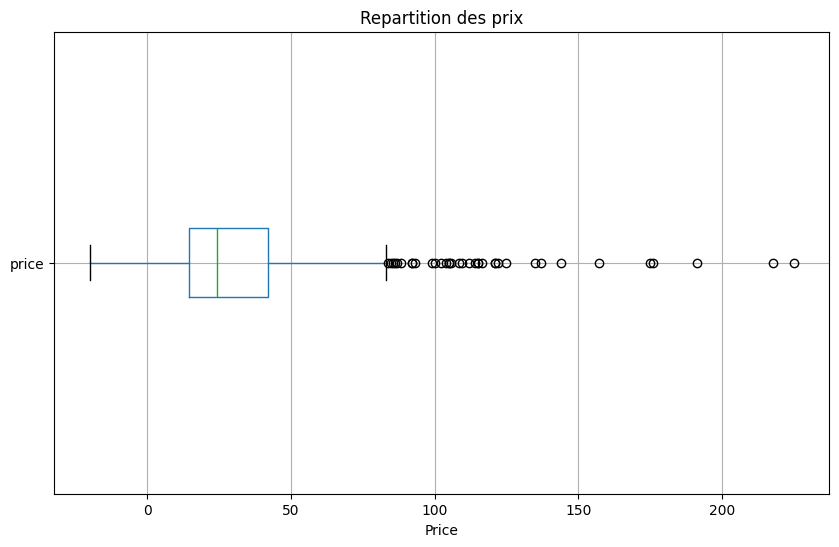

In [ ]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10,6))
full_merge.boxplot(column='price', vert=False)
plt.title('Repartition des prix')
plt.xlabel('Price')
plt.show()

In [ ]:
#Autre méthode avec plotly express
fig= px.box(full_merge,x='price',title='Repartition des prix')
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [ ]:
#Calculer la moyenne du prix
print('la moyenne du prix est')
moyenne_prix = full_merge['price'].mean()
print(moyenne_prix)
#Calculer l'écart-type du prix
print('l ecart type du prix est de')
ecart_type_prix = full_merge['price'].std()
print(ecart_type_prix)
#Calculer le Z-score
print('le Z-score est de')
z_score_prix =(moyenne_prix)/ecart_type_prix
print(z_score_prix)


la moyenne du prix est
32.19969623329283
l ecart type du prix est de
26.729902344527954
le Z-score est de
1.2046320191620392


In [ ]:
#Quel est le seuil prix dont z-score est supérieur à 3?
outlier_df = full_merge[full_merge['price'].apply(lambda x: np.abs(x-moyenne_prix)/(ecart_type_prix)>3)]
print("le seuil prix dont z-score supérieur à 3 est",outlier_df['price'].min())

le seuil prix dont z-score supérieur à 3 est 114.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [ ]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
full_merge['price'].describe()

,price
count,823.000000
mean,32.199696
std,26.729902
min,-20.000000
25%,14.500000
50%,24.300000
75%,41.900000
max,225.000000


In [ ]:
#Définissez un seuil pour les articles "outliers" en prix
Q1 = full_merge['price'].quantile(0.25)
Q3 = full_merge['price'].quantile(0.75)
IQR = Q3-Q1
print("l'interval interquartile est de")
print(IQR)
print("le seuil de prix est de")
prix_seuil_inf = (Q1 - 1.5*IQR)
prix_seuil_sup = (Q3 + 1.5*IQR)
print (prix_seuil_inf)
print(prix_seuil_sup)

l'interval interquartile est de
27.4
le seuil de prix est de
-26.599999999999994
83.0


In [ ]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
stock_outlier = full_merge[(full_merge['price']<prix_seuil_inf)|(full_merge['price']>prix_seuil_sup)]
nbre_article_outlier = stock_outlier.shape[0]
prop_article_outlier=round((nbre_article_outlier/full_merge.shape[0])*100,2)
print("le nombre d'article de l'ensemble du catalogue des outliers est",nbre_article_outlier)
print("la proporation des articles outliers est de",prop_article_outlier)

le nombre d'article de l'ensemble du catalogue des outliers est 36
la proporation des articles outliers est de 4.36


In [ ]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
stock_outlier.head(50)
print("les articles outliers semblent être de luxe, car les valeurs product type sont du vin,Whisky, champagne donc ils ne sont pas en anomalies")

les articles outliers semblent être de luxe, car les valeurs product type sont du vin,Whisky, champagne donc ils ne sont pas en anomalies


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créez une colonne calculant le CA par article
full_merge['CA']=full_merge['price']*full_merge['total_sales']
#Calculez la somme de la colonne "ca_par_article"
sum_ca = full_merge['CA'].sum()
print("la somme du chiffre d'affaire est de")
print(sum_ca)
#Ce résultat correspond au chiffre d'affaire du site web
CA_site_web = full_merge.loc[full_merge['onsale_web']==1,'CA'].sum()
print(CA_site_web)
print("le resulat du CA site web est legerement inférieur au CA du catalogue entier")

la somme du chiffre d'affaire est de
143324.1
143242.9
le resulat du CA site web est legerement inférieur au CA du catalogue entier


In [ ]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
full_merge = full_merge.sort_values(by='CA',ascending=False)
#Réinitialiser l'index du dataset par un reset_index
full_merge.reset_index(drop=True,inplace=True)
#Afficher les 20 premier articles en CA
df_20lines = full_merge.head(20)
print(df_20lines)
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_20lines[::-1], x="CA",y="post_title", title="Palmares des 20 pemiers articles en CA")
fig.show()


    product_id  onsale_web  price  stock_quantity stock_status  \
0       4352.0         1.0  225.0             0.0   outofstock   
1       5892.0         1.0  191.3            98.0      instock   
2       4353.0         1.0   79.5           127.0      instock   
3       5826.0         1.0   41.2            34.0      instock   
4       6212.0         1.0  115.0            16.0      instock   
5       5026.0         1.0   86.8           101.0      instock   
6       5008.0         1.0  105.0            12.0      instock   
7       5767.0         1.0  175.0            12.0      instock   
8       6126.0         1.0  135.0           138.0      instock   
9       5025.0         1.0  112.0           136.0      instock   
10      6201.0         1.0  105.6            16.0      instock   
11      4406.0         1.0  157.0            12.0      instock   
12      4647.0         1.0   28.5            45.0      instock   
13      4358.0         1.0   77.0            81.0      instock   
14      43

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
full_merge = full_merge.assign(part_ca=full_merge['CA']/full_merge['CA'].sum())
full_merge.head()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
full_merge=full_merge.assign(cum_part_ca=full_merge['part_ca'].cumsum())
full_merge.head()
# Grâce au deux colonnes créées précedemment, calculer le nombre d'articles
# représentant 80% du CA
cumsum_80 = full_merge.loc[full_merge["cum_part_ca"] < 0.8]
print(cumsum_80)
nb_article_80 = cumsum_80.shape[0]
print("Articles total représentant 80% du CA :\n",nb_article_80)
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
Prop_80_arti = (nb_article_80/full_merge.shape[0])*100
print("la proportion représentant les 80% sur l'ensemble du catalogue est : ",Prop_80_arti)

     product_id  onsale_web  price  stock_quantity stock_status  \
0        4352.0         1.0  225.0             0.0   outofstock   
1        5892.0         1.0  191.3            98.0      instock   
2        4353.0         1.0   79.5           127.0      instock   
3        5826.0         1.0   41.2            34.0      instock   
4        6212.0         1.0  115.0            16.0      instock   
..          ...         ...    ...             ...          ...   
428      4978.0         1.0   18.5            23.0      instock   
429      4664.0         1.0   16.4            20.0      instock   
430      4728.0         1.0   29.5            14.0      instock   
431      4075.0         1.0   14.7            35.0      instock   
432      4865.0         1.0    9.8            48.0      instock   

     purchase_price id_web    sku  total_sales tax_status product_type  \
0            137.81  15940  15940         11.0    taxable    Champagne   
1            116.06  14983  14983          6.0 

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [ ]:
#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
full_merge = full_merge.sort_values(by='CA',ascending=False)

In [ ]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
full_merge = full_merge.sort_values(by='total_sales',ascending=False)
#Réinitialiser l'index du dataset par un reset_index
full_merge.reset_index(drop=True,inplace=True)
#Afficher les 20 premier articles en quantité
df_qu_20 = full_merge.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
fig2= px.histogram(df_qu_20[::-1],x='total_sales', y="post_title", title='Analyse des ventes en quantités')
fig2.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
full_merge = full_merge.assign(part_quant=full_merge['total_sales']/full_merge['total_sales'].sum())
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
full_merge=full_merge.assign(cum_part_quant=full_merge['part_quant'].cumsum())
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
quant_cumsum_80 = full_merge.loc[full_merge["cum_part_quant"] < 0.8]
nb_article_quant_80 = quant_cumsum_80.shape[0]
print("Articles total représentant 80% des quantités vendues :\n",nb_article_quant_80)
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
Prop_80_arti_vendues = (nb_article_quant_80/full_merge.shape[0])*100
print("la proportion représentant les 80% sur l'ensemble du catalogue est : ",Prop_80_arti_vendues)

Articles total représentant 80% des quantités vendues :
 424
la proportion représentant les 80% sur l'ensemble du catalogue est :  51.3317191283293


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [ ]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np
#Création de la colonne Rotation de stock
full_merge['Rotation stock']= full_merge["stock_quantity"] / full_merge["total_sales"]
#Remplacement des "inf" par 0
full_merge['Rotation stock'] = full_merge['Rotation stock'].replace([np.inf],0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
full_merge = full_merge.sort_values(by='Rotation stock', ascending=False)
full_merge.reset_index(drop=True,inplace=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
df_stock_20 = full_merge.head(20)
fig3= px.histogram(df_stock_20[::-1],x='Rotation stock', y="post_title", title='top 20 articles qui ont le plus de mois de stock')
fig3.show()

In [ ]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
full_merge ['Valorisation_stock_euros']= full_merge['stock_quantity']*full_merge['price']
#Calculer la somme de la colonne "Valorisation_stock_euros"
print("la somme de la valorisation des stocks est de")
round(full_merge['Valorisation_stock_euros'].sum())

la somme de la valorisation des stocks est de


531773

In [ ]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print("le nombre de bouteille dans notre stock est de {} ".format(full_merge["stock_quantity"].sum()))

le nombre de bouteille dans notre stock est de 17822.0 


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
full_merge["price_HT"] = full_merge["price"] / (1.2) # TVA = 20%

#Création de la colonne Taux de marge
full_merge["taux_marge"] = (full_merge["price_HT"] - full_merge["purchase_price"]) / full_merge["price_HT"]

#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge le plus bas: {}".format(full_merge["taux_marge"].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge le plus haut: {}".format(full_merge["taux_marge"].max()))

Le taux de marge le plus bas: -6.3498814229249
Le taux de marge le plus haut: 1.651


In [ ]:
#affichage de la ligne avec un taux de marge inférieur à 0
full_merge[full_merge['taux_marge'] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,...,post_type,CA,part_ca,cum_part_ca,part_quant,cum_part_quant,Rotation stock,Valorisation_stock_euros,price_HT,taux_marge
671,4355.0,1.0,12.65,97.0,instock,77.48,12589,12589,0.0,taxable,...,product,0.0,0.0,1.0,0.0,1.012857,0.0,1227.05,10.541667,-6.349881
728,4864.0,0.0,8.30,0.0,outofstock,9.99,15154,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,6.916667,-0.444337
771,6324.0,0.0,92.00,18.0,instock,99.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1656.00,76.666667,-0.291304
821,7196.0,0.0,31.00,55.0,instock,31.20,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1705.00,25.833333,-0.207742


In [ ]:
#création d'un dataframe avec les taux positifs
df_taux_positif = full_merge[full_merge['taux_marge'] >= 0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge le plus bas: {}".format(df_taux_positif["taux_marge"].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge le plus haut: {}".format(df_taux_positif["taux_marge"].max()))

Le taux de marge le plus bas: 0.22778625954198473
Le taux de marge le plus haut: 1.651


In [ ]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_marge = df_taux_positif.groupby('product_type')['taux_marge'].mean().reset_index()
df_taux_marge.sort_values(by='taux_marge',inplace=True)
#Affichage dans un graphique du taux de marge par type de produit
px.bar(df_taux_marge, y="taux_marge", x="product_type", orientation="v", title="Taux de marge par type de produit")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

[[1. 1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 1.]]


<Axes: >

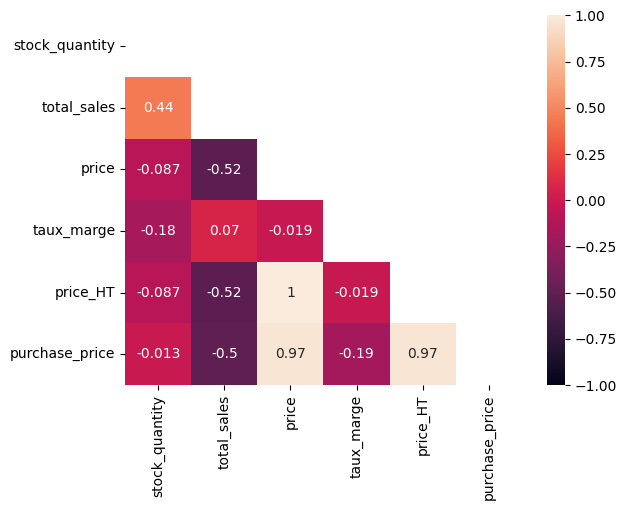

In [ ]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns

#Création d'un heatmap de correlation avec les variables stock, sales et price
#on peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(full_merge[["stock_quantity", "total_sales", "price", "taux_marge", "price_HT", "purchase_price"]].corr()))
mask
print(mask)
sns.heatmap(full_merge[["stock_quantity", "total_sales", "price", "taux_marge", "price_HT", "purchase_price"]].corr(), vmin=-1, vmax=1, annot=True, mask=mask)

In [ ]:
#Que peut-on conclure des correlations ?
# plus elle est proche de 1 et plus il y a une corrélation et plus elle est proche de 0 et moins il y a une corrélation entre les variables
""

''

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.
full_merge.to_excel("full_merge.xlsx", index=False)